In [ ]:
!pip install ucimlrepo


In [14]:
import pandas as pd

raw_data = [
    {"text": "Go until jurong point, crazy.. Available only in bugis n great world la e buffet...", "label": "ham"},
        {"text": "Ok lar... Joking wif u oni...", "label": "ham"},
            {"text": "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005.", "label": "spam"},
                {"text": "U dun say so early hor... U c already then say...", "label": "ham"},
                    {"text": "Nah I don't think he goes to usf, he lives around here though", "label": "ham"},
                        {"text": "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Txt chat to Pd-XML, ok!", "label": "spam"},
                            {"text": "Even my brother is not like to speak with me. They treat me like aids patent.", "label": "ham"},
                                {"text": "As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers.", "label": "ham"},
                                    {"text": "WINNER!! As a valued network customer you have been selected to receivea £900 prize reward!", "label": "spam"},
                                        {"text": "Had your mobile 11 months or more? U R entitled to update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030", "label": "spam"},
                                            {"text": "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.", "label": "ham"},
                                                {"text": "SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info", "label": "spam"},
                                                    {"text": "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18", "label": "spam"},
                                                        {"text": "I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise.", "label": "ham"},
                                                            {"text": "I HAVE A DATE ON SUNDAY WITH WILL!!", "label": "ham"},
                                                                {"text": "XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://xxxmobilemovieclub.com", "label": "spam"},
                                                                    {"text": "Oh k...i'm watching here:) ", "label": "ham"},
                                                                        {"text": "Eh u remember how 2 spell his name... Yes i did. He v naughty make u v wet.", "label": "ham"},
                                                                            {"text": "Fine if that's the way u feel. That's the way its gota be", "label": "ham"},
                                                                                {"text": "England v Macedonia - dont miss the goals/team news. Txt ur national team to 87077 eg ENGLAND to 87077 Try:WALES, SCOTLAND 4txt/ú1.20 POBOXox36504W45WQ 16+", "label": "spam"},
                                                                                    {"text": "Is that seriously how you spell his name?", "label": "ham"},
                                                                                        {"text": "I‘m going to try for 2 months ha ha only joking", "label": "ham"},
                                                                                            {"text": "So ü pay first lar... Then when is da stock comin...", "label": "ham"},
                                                                                                {"text": "Aft i finish my lunch then i go str down lor. Ard 3 smth u fin u car anywre.", "label": "ham"},
                                                                                                    {"text": "Ffffffffff. Alright no way I can meet up with you sooner?", "label": "ham"},
                                                                                                        {"text": "Just forced myself to eat a slice. I'm really not hungry tho. This sucks. Mark is getting worried. He knows I'm sick when I turn down pizza. Lol", "label": "ham"},
                                                                                                            {"text": "Lol your always so convincing.", "label": "ham"},
                                                                                                                {"text": "Did you catch the bus ? Are you left an hour ago", "label": "ham"},
                                                                                                                    {"text": "I'm back & we're packing the car now, I'll let you know if there's room", "label": "ham"},
                                                                                                                        {"text": "Ahhh. Work. I vaguely remember that! What does it feel like? Lol", "label": "ham"},
                                                                                                                            {"text": "Wait that's still his clear", "label": "ham"},
                                                                                                                                {"text": "Yeah he got in at 2 and nelson keyed it in ú8g..", "label": "ham"},
                                                                                                                                    {"text": "With our service you get free text messages options.", "label": "spam"},
                                                                                                                                        {"text": "Your package is ready for delivery. Urgent action required to claim your prize.", "label": "spam"},
                                                                                                                                            {"text": "This offer is valid for a limited time only. Win big rewards tonight.", "label": "spam"}
                                                                                                                                            ]

df = pd.DataFrame(raw_data)

print(len(df))
print(df.isnull().sum())

df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(len(df))

df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})


35
text     0
label    0
dtype: int64
35


11 0.3142857142857143
24 0.6857142857142857


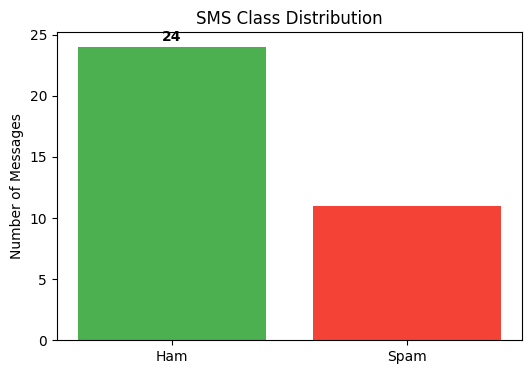

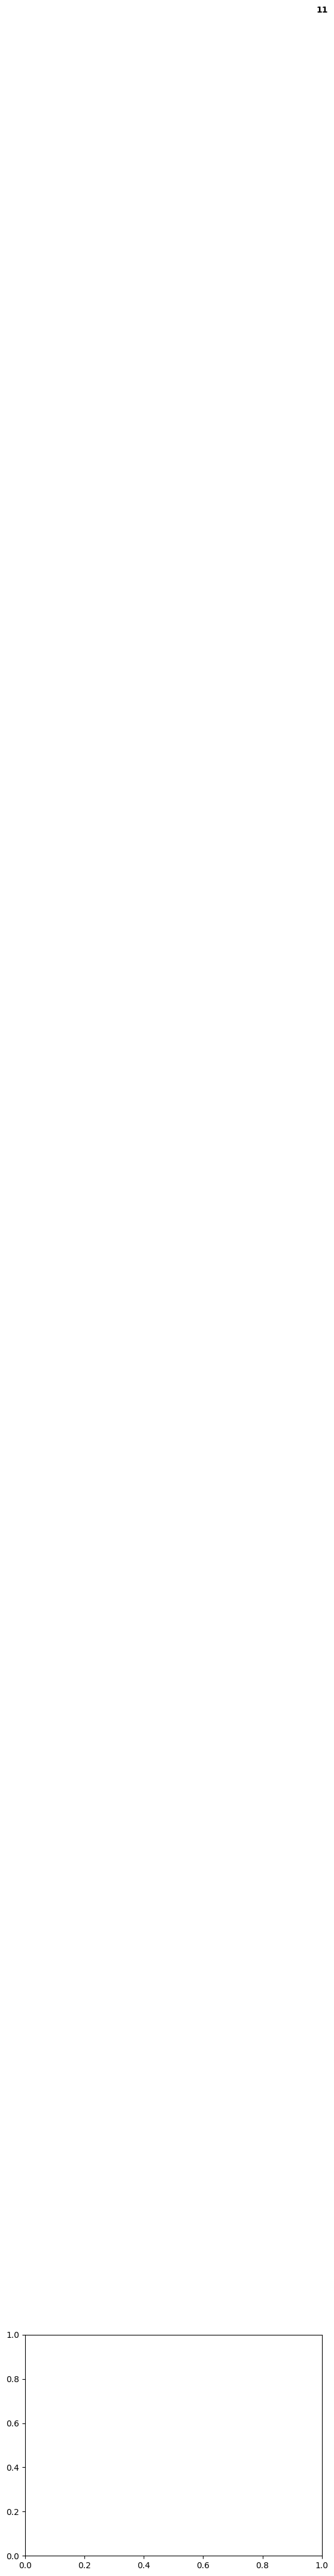

In [16]:
import numpy as np
import matplotlib.pyplot as plt

total_messages = len(df)
spam_count = df['label_num'].sum()
ham_count = total_messages - spam_count

p_spam = spam_count / total_messages
p_ham = ham_count / total_messages

print(spam_count, p_spam)
print(ham_count, p_ham)

plt.figure(figsize=(6, 4))
plt.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#4CAF50', '#F44336'])
plt.title('SMS Class Distribution')
plt.ylabel('Number of Messages')
for i, v in enumerate([ham_count, spam_count]):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
    plt.show()



In [18]:
#CELL4
import re
suspicious_words=['free','prize','win','urgent','offer']
for word in suspicious_words:
  contains_word=df['text'].str.contains(rf'\b{word}\b',flags=re.IGNORECASE,regex=True)
  total_word=contains_word.sum()
  if total_word==0:
     continue
  spam_with_word=df[contains_word]['label_num'].sum()
  ham_with_word=total_word-spam_with_word
  p_spam_given_word_direct=spam_with_word/total_word
  p_word_given_spam=spam_with_word/spam_count
  p_word_given_ham=ham_with_word/ham_count
  p_word=total_word/total_messages
  p_spam_given_word_bayes=(p_word_given_spam*p_spam)/p_word
  print(f"Word:{word}")
  print(f"Direct:{p_spam_given_word_direct:.4f}")
  print(f"Bayes:{p_spam_given_word_bayes:.4f}\n")


Word:free
Direct:1.0000
Bayes:1.0000

Word:prize
Direct:1.0000
Bayes:1.0000

Word:win
Direct:1.0000
Bayes:1.0000

Word:urgent
Direct:1.0000
Bayes:1.0000

Word:offer
Direct:1.0000
Bayes:1.0000



In [19]:

expected_value_Y=p_spam
variance_Y=p_spam*(1-p_spam)
print(f"E(Y)={expected_value_Y:.4f}")
print(f"Var(Y)={variance_Y:.4f}")


E(Y)=0.3143
Var(Y)=0.2155


In [20]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
X=df['text']
y=df['label_num']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
vectorizer=CountVectorizer(stop_words='english')
X_train_counts=vectorizer.fit_transform(X_train)
X_test_counts=vectorizer.transform(X_test)
model=MultinomialNB()
model.fit(X_train_counts,y_train)


MultinomialNB()

In [21]:

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred=model.predict(X_test_counts)
print(classification_report(y_test,y_pred,target_names=['Ham','Spam']))
cm=confusion_matrix(y_test,y_pred)
print(cm)
false_positives=cm[0][1]
false_negatives=cm[1][0]
print(f"False Positives:{false_positives}")
print(f"False Negatives:{false_negatives}")


              precision    recall  f1-score   support

         Ham       0.83      1.00      0.91         5
        Spam       1.00      0.50      0.67         2

    accuracy                           0.86         7
   macro avg       0.92      0.75      0.79         7
weighted avg       0.88      0.86      0.84         7

[[5 0]
 [1 1]]
False Positives:0
False Negatives:1


In [22]:

def test_new_message(custom_message):
    transformed_msg=vectorizer.transform([custom_message])
    prediction=model.predict(transformed_msg)
    pred_label="Spam" if prediction==1 else "Ham"
    probabilities=model.predict_proba(transformed_msg)[0]
    print(f"Message:{custom_message}")
    print(f"Prediction:{pred_label}")
    print(f"P(Spam|Message)={probabilities[1]:.4f}")
    print(f"P(Ham|Message)={probabilities[0]:.4f}\n")
test_new_message("Congratulations! You have won a free prize. Claim now.")
test_new_message("Hey, are we still meeting for lunch today at 1 PM?")


Message:Congratulations! You have won a free prize. Claim now.
Prediction:Spam
P(Spam|Message)=0.8247
P(Ham|Message)=0.1753

Message:Hey, are we still meeting for lunch today at 1 PM?
Prediction:Ham
P(Spam|Message)=0.3200
P(Ham|Message)=0.6800



In [23]:

Custom_SMS_Message="URGENT! Your mobile number has won a prize. Call 09061701461 to claim."#@param {type:"string"}
test_new_message(Custom_SMS_Message)


Message:URGENT! Your mobile number has won a prize. Call 09061701461 to claim.
Prediction:Spam
P(Spam|Message)=0.7385
P(Ham|Message)=0.2615

